In [1]:
import os
import random
import torch
from torchvision.utils import save_image
import torch
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"

batch_size = 32
latent_dim = 100
threshold = 0.8
import numpy as np

import matplotlib.pyplot as plt


Настав час нагенерувати зображення. Чомусь в pytorch в останні роки додали якийсь дивний захист при завантаженні моделей, тому змінюємо визначення вивантаження. Визначаємо наші 2 типи моделей що б вивантажити в них збережені стани

In [2]:
_original_torch_load = torch.load

def _trusted_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return _original_torch_load(*args, **kwargs)

torch.load = _trusted_load

In [3]:
#https://github.com/m-bain/whisperX/issues/1304

In [4]:


class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),

            nn.Dropout(0.4),

            nn.Linear(512 * 4 * 4, 1),

            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()

        self.latent_dim = latent_dim

        self.dense = nn.Sequential(
            nn.Linear(latent_dim, 256 * 8 * 8)
        )


        self.main = nn.Sequential(
            nn.ConvTranspose2d(
                256,
                128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Upsample(scale_factor=2),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            #nn.Upsample(scale_factor=2),

            #nn.Conv2d(128, 128, kernel_size=3, padding=1),
            #nn.BatchNorm2d(128),
            #nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(
                128,
                128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                128,
                3,
                kernel_size=3,
                padding=1
            ),

            nn.Tanh()
        )

    def forward(self, c):
        x = self.dense(c)

        x = x.view(-1, 256, 8, 8)

        x = self.main(x)

        return x


Вантажимо збережені стани з останньої збереженої моделі для кожного з менших класів. При збережені будемо генерувати випадкову назву згенерованій карті. Дивимось на семпл, обираємо трешолд "обману" збереженого дискримінатора для зменшення кількості погано згенерованих зображень. Від всіх погано згенерованих зображень не врятує, але якесь відсіювання буде.

In [23]:
generator = Generator(latent_dim)
generator.to(device)
discriminator = Discriminator()
discriminator.to(device)
folder = "generated_images/king"
os.makedirs(folder, exist_ok=True)

generator.load_state_dict(torch.load('kingly_generator_999.pth', weights_only=True))
generator.eval()

discriminator.load_state_dict(torch.load('kingly_discriminator_999.pth', weights_only=True))
discriminator.eval()



titles = [
    "monarch",
    "king",
    "emperor",
    "ruler",
    "sovereign",
    "caesar",
    "overlord",
    "regent",
    "imperator",
    "dad"
]

In [24]:
# Проглянемо пробу згенерованих зображень та визначемо treshold омани дискриминатора. Вочевидь значення буде значуще нижче 0.8 оскільки дискримінатор натренован шукати згенеровані зображення

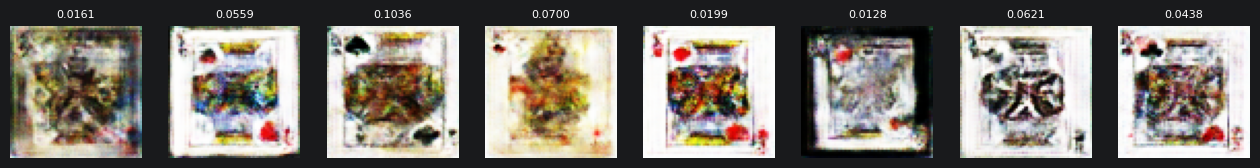

In [10]:
batch_size = 8
with torch.no_grad():


    noise = torch.randn(batch_size, latent_dim).to(device)
    gen = generator(noise).to(device)
    scores = discriminator(gen).view(-1)
    fig, axes = plt.subplots(1, batch_size, figsize=(batch_size*2, 2))
    for i in range(batch_size):

        score = scores[i].item()


        random_name = random.choice(titles)
        random_number = random.randint(1000, 77777777777)
        filename = f"{random_name}_{random_number}.png"

        img = gen[i].detach().cpu()
        img = (img + 1) / 2

        img = img.permute(1, 2, 0).numpy()

        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"{score:.4f}", fontsize=8)

        if score >= threshold:

            save_path = os.path.join(folder, filename)

            save_image(img, save_path)

In [25]:
new_threshold = 0.018

# Нехай межа - 0.018

In [26]:

for i in range(400):
    with torch.no_grad():


        noise = torch.randn(batch_size, latent_dim).to(device)
        gen = generator(noise).to(device)
        scores = discriminator(gen).view(-1)
        for i in range(batch_size):

            score = scores[i].item()


            random_name = random.choice(titles)
            random_number = random.randint(1000, 77777777777)
            filename = f"{random_name}_{random_number}.png"

            img = gen[i].detach().cpu()
            img = (img + 1) / 2

            if score >= new_threshold:

                save_path = os.path.join(folder, filename)

                save_image(img, save_path)

In [27]:
generator = Generator(latent_dim)
generator.to(device)
discriminator = Discriminator()
discriminator.to(device)
folder = "generated_images/queen"
os.makedirs(folder, exist_ok=True)

generator.load_state_dict(torch.load('queen_generator_999.pth', weights_only=True))
generator.eval()

discriminator.load_state_dict(torch.load('queen_discriminator_999.pth', weights_only=True))
discriminator.eval()

titles = [
    "queen",
    "empress",
    "regent",
    "duchess",
    "princess",
]


In [14]:
import numpy as np

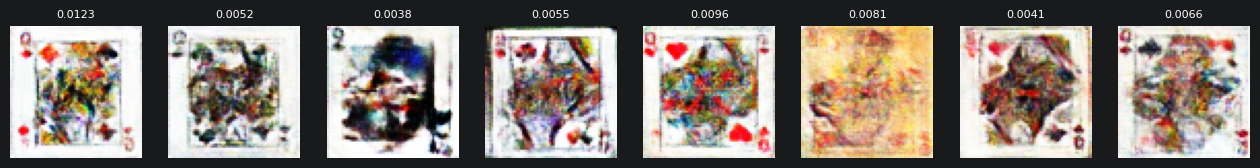

In [15]:
batch_size = 8
with torch.no_grad():


    noise = torch.randn(batch_size, latent_dim).to(device)
    gen = generator(noise).to(device)
    scores = discriminator(gen).view(-1)
    fig, axes = plt.subplots(1, batch_size, figsize=(batch_size*2, 2))
    for i in range(batch_size):

        score = scores[i].item()


        random_name = random.choice(titles)
        random_number = random.randint(1000, 77777777777)
        filename = f"{random_name}_{random_number}.png"

        img = gen[i].detach().cpu()
        img = (img + 1) / 2

        img = img.permute(1, 2, 0).numpy()

        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"{score:.4f}", fontsize=8)

        if score >= threshold:

            save_path = os.path.join(folder, filename)

            save_image(img, save_path)

In [28]:
new_threshold = 0.004

# Нехай межа - 0.004
for i in range(400):
    with torch.no_grad():


        noise = torch.randn(batch_size, latent_dim).to(device)
        gen = generator(noise).to(device)
        scores = discriminator(gen).view(-1)
        for i in range(batch_size):

            score = scores[i].item()


            random_name = random.choice(titles)
            random_number = random.randint(1000, 77777777777)
            filename = f"{random_name}_{random_number}.png"

            img = gen[i].detach().cpu()
            img = (img + 1) / 2

            if score >= new_threshold:

                save_path = os.path.join(folder, filename)

                save_image(img, save_path)

In [29]:
generator = Generator(latent_dim)
generator.to(device)
discriminator = Discriminator()
discriminator.to(device)
folder = "generated_images/jack"
os.makedirs(folder, exist_ok=True)

generator.load_state_dict(torch.load('jack_generator_999.pth', weights_only=True))
generator.eval()

discriminator.load_state_dict(torch.load('jack_discriminator_999.pth', weights_only=True))
discriminator.eval()
titles = [
    "jack",
    "squire",
    "bachelor",
    "student",
    "servant",
    "knight"
]

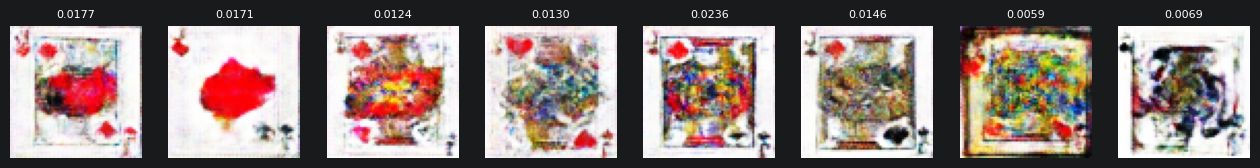

In [33]:
batch_size = 8
with torch.no_grad():


    noise = torch.randn(batch_size, latent_dim).to(device)
    gen = generator(noise).to(device)
    scores = discriminator(gen).view(-1)
    fig, axes = plt.subplots(1, batch_size, figsize=(batch_size*2, 2))
    for i in range(batch_size):

        score = scores[i].item()


        random_name = random.choice(titles)
        random_number = random.randint(1000, 77777777777)
        filename = f"{random_name}_{random_number}.png"

        img = gen[i].detach().cpu()
        img = (img + 1) / 2

        img = img.permute(1, 2, 0).numpy()

        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"{score:.4f}", fontsize=8)

        if score >= threshold:

            save_path = os.path.join(folder, filename)

            save_image(img, save_path)

In [34]:
new_threshold = 0.012

# Нехай межа - 0.012
for i in range(400):
    with torch.no_grad():


        noise = torch.randn(batch_size, latent_dim).to(device)
        gen = generator(noise).to(device)
        scores = discriminator(gen).view(-1)
        for i in range(batch_size):

            score = scores[i].item()


            random_name = random.choice(titles)
            random_number = random.randint(1000, 77777777777)
            filename = f"{random_name}_{random_number}.png"

            img = gen[i].detach().cpu()
            img = (img + 1) / 2

            if score >= new_threshold:

                save_path = os.path.join(folder, filename)

                save_image(img, save_path)

In [35]:
generator = Generator(latent_dim)
generator.to(device)
discriminator = Discriminator()
discriminator.to(device)
folder = "generated_images/xxx"
os.makedirs(folder, exist_ok=True)

generator.load_state_dict(torch.load('xxx_generator_299.pth', weights_only=True))
generator.eval()

discriminator.load_state_dict(torch.load('xxx_discriminator_299.pth', weights_only=True))
discriminator.eval()
titles = [
    "joker",
    "fool",
    "clown",
    "jester",
    "wildcard",
    "balatro"
]

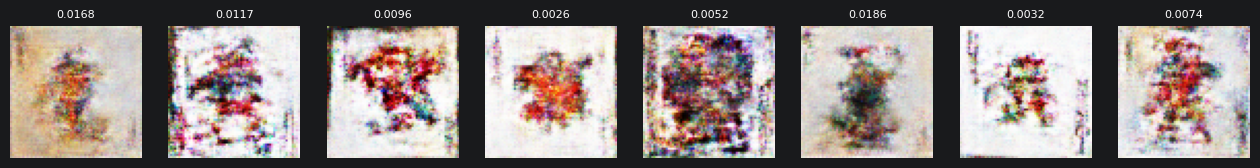

In [21]:
batch_size = 8
with torch.no_grad():


    noise = torch.randn(batch_size, latent_dim).to(device)
    gen = generator(noise).to(device)
    scores = discriminator(gen).view(-1)
    fig, axes = plt.subplots(1, batch_size, figsize=(batch_size*2, 2))
    for i in range(batch_size):

        score = scores[i].item()


        random_name = random.choice(titles)
        random_number = random.randint(1000, 77777777777)
        filename = f"{random_name}_{random_number}.png"

        img = gen[i].detach().cpu()
        img = (img + 1) / 2

        img = img.permute(1, 2, 0).numpy()

        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"{score:.4f}", fontsize=8)

        if score >= threshold:

            save_path = os.path.join(folder, filename)

            save_image(img, save_path)

In [36]:
new_threshold = 0.002

# Нехай межа - 0.002
for i in range(400):
    with torch.no_grad():


        noise = torch.randn(batch_size, latent_dim).to(device)
        gen = generator(noise).to(device)
        scores = discriminator(gen).view(-1)
        for i in range(batch_size):

            score = scores[i].item()


            random_name = random.choice(titles)
            random_number = random.randint(1000, 77777777777)
            filename = f"{random_name}_{random_number}.png"

            img = gen[i].detach().cpu()
            img = (img + 1) / 2

            if score >= new_threshold:

                save_path = os.path.join(folder, filename)

                save_image(img, save_path)